In [2]:
from utils import *
from concurrent.futures import ProcessPoolExecutor
import concurrent
from scqubits import *
import numpy as np

In [3]:

EJ = 3


EC_subdivisions = 200
EL_subdivisions = 200
EC_values = np.linspace(0.1,1.2, EC_subdivisions)
EL_values = np.linspace(0.01, 0.17, EL_subdivisions)

EC_grid,EL_grid = np.meshgrid(EC_values, EL_values)

EC_flat = EC_grid.flatten()
EL_flat = EL_grid.flatten()

# results = np.vectorize(get_estimations)(EC_flat, EL_flat)


if os.path.exists('temp_functions.py'):
    os.remove('temp_functions.py')

# Create 'temp_functions.py' and write the process_pair function to it
with open('temp_functions.py', 'w') as f:
    f.write(f"""
from scqubits import Fluxonium
from utils import get_shift
import numpy as np
            
def get_estimations(EC, EL):
    # try:
    qubit_level = 25
    qbt = Fluxonium(EJ={EJ},EC=EC,EL=EL,flux=0,cutoff=110,truncated_dim=qubit_level)
    
    num_evals = 20
    evals = qbt.eigenvals(num_evals)
    Er  = evals[9]-evals[0]
    elements = qbt.matrixelement_table('n_operator',evals_count = num_evals)
    shifts_from_one = [get_shift(elements[1,ql2],evals[ql2]-evals[1]-Er) for ql2 in range(num_evals)] 
    shift_from_one = sum(shifts_from_one)
    shifts_from_two = [get_shift(elements[2,ql2],evals[ql2]-evals[2]-Er) for ql2 in range(num_evals)] 
    shift_from_two = sum(shifts_from_two)

    results = (evals[2]-evals[1], # qubit freq, want 10 MHz
                shift_from_one, 
                shift_from_two, 
                abs(shift_from_one-shift_from_two)
            )
    results = tuple(x if np.shape(x) == () else None for x in results)
    return results
            
def process_pair(args):
    i, (ec, el) = args
    result = get_estimations(ec, el)
    return i, result
""")

# Import process_pair from the temporary file
from temp_functions import process_pair, get_estimations

from concurrent.futures import ProcessPoolExecutor, as_completed

results_0, results_1, results_2, results_3 = [None] * len(EC_flat), [None] * len(EC_flat), [None] * len(EC_flat), [None] * len(EC_flat)


# Create a ProcessPoolExecutor object for parallelization
with ProcessPoolExecutor(max_workers=1) as executor:
    # Initialize tqdm
    pbar = tqdm(total=len(EC_flat))

    futures = {executor.submit(process_pair, args): args for args in enumerate(zip(EC_flat, EL_flat))}

    for future in as_completed(futures):
        i, result = future.result()
        
        # Append the results to the corresponding lists at the correct index
        results_0[i] = result[0]
        results_1[i] = result[1]
        results_2[i] = result[2]
        results_3[i] = result[3]

        # Update the tqdm progress bar
        pbar.update(1)


# Convert the lists to NumPy arrays
results_0, results_1, results_2, results_3 = map(np.array, [results_0, results_1, results_2, results_3])

# Combine the individual arrays into a tuple
results = (results_0, results_1, results_2, results_3)

# Delete 'temp_functions.py'
if os.path.exists('temp_functions.py'):
    os.remove('temp_functions.py')

  0%|          | 0/40000 [00:00<?, ?it/s]

In [4]:

num_elements_in_result = 4 #number of values produced for one set of parameters.
shape_of_grid = (EC_subdivisions, EL_subdivisions)
list_of_grid = [np.zeros(shape_of_grid,dtype=np.float32) for _ in range(num_elements_in_result)]
# Initialize counter for existing chunks
existing_chunk_num = 0
total_elements = EC_subdivisions* EL_subdivisions

# Initialize flattened arrays to store the results for this EJ value
list_of_flat = [np.zeros(total_elements) for _ in range(num_elements_in_result)]

# Place the results back into the flattened arrays
for idx, element in enumerate(results):
    list_of_flat[idx] = element

# Reshape the flattened arrays back into the original grid for this EJ value
for idx, grid in enumerate(list_of_grid):
    grid[ :, :] = list_of_flat[idx].reshape(shape_of_grid)


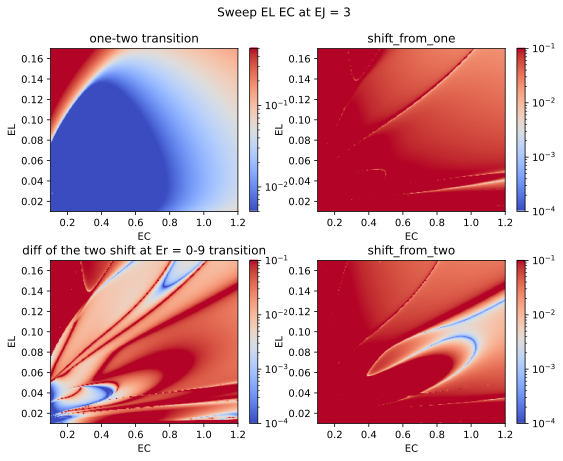

In [5]:
from matplotlib.colors import LogNorm, SymLogNorm
from ipywidgets import interact, FloatSlider
import matplotlib.pyplot as plt
import numpy as np

extent = (EC_values[0], EC_values[-1], EL_values[0], EL_values[-1])
qubit_freq_diff_norm = LogNorm(vmin=1e-4,vmax=1e-1)

fig, axes = plt.subplots(2, 2, figsize=(8, 6.5))


# First subplot
im1 = axes[0, 0].imshow(list_of_grid[0][:, :], extent=extent, origin='lower', aspect='auto',
                        norm=LogNorm(vmax=5e-1, vmin=5e-3), cmap='coolwarm')
fig.colorbar(im1, ax=axes[0, 0], label='')
axes[0, 0].set_title(f'one-two transition')
axes[0, 0].set_xlabel('EC')
axes[0, 0].set_ylabel('EL')

# Second subplot
im2 = axes[0, 1].imshow(abs(list_of_grid[1][:, :]), extent=extent,
                        origin='lower', aspect='auto', norm=qubit_freq_diff_norm, cmap='coolwarm')
fig.colorbar(im2, ax=axes[0, 1], label='')
axes[0, 1].set_title(f'shift_from_one')
axes[0, 1].set_xlabel('EC')
axes[0, 1].set_ylabel('EL')

# Third subplot
im3 = axes[1, 1].imshow(abs(list_of_grid[2][:, :]), extent=extent,
                        origin='lower', aspect='auto', norm=qubit_freq_diff_norm, cmap='coolwarm')
fig.colorbar(im3, ax=axes[1, 1], label='')
axes[1, 1].set_title(f'shift_from_two')
axes[1, 1].set_xlabel('EC')
axes[1, 1].set_ylabel('EL')

# Fourth subplot
im4 = axes[1, 0].imshow(list_of_grid[3][:, :] ,
                        extent=extent, origin='lower', aspect='auto', norm=qubit_freq_diff_norm, cmap='coolwarm')
fig.colorbar(im4, ax=axes[1, 0], label='')
axes[1, 0].set_title(f'diff of the two shift at Er = 0-9 transition')
axes[1, 0].set_xlabel('EC')
axes[1, 0].set_ylabel('EL')
fig.suptitle('Sweep EL EC at EJ = 3')
plt.tight_layout()
plt.subplots_adjust(wspace=0.14, hspace=0.3)
plt.show()